In [1]:
# ============================================================
# Mount Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install -q lightgbm==4.1.0 imbalanced-learn==0.12.3 h5py

import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import ADASYN
from collections import Counter
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 25.0 MB/s eta 0:00:00


In [3]:
# ============================================================
# Paths
# ============================================================
paths = {
    "train": "/content/drive/My Drive/Embedding_Concatenate_4Class/Train_4class.csv",
    "val":   "/content/drive/My Drive/Embedding_Concatenate_4Class/Val_4class.csv",
    "test":  "/content/drive/My Drive/Embedding_Concatenate_4Class/Test_4class.csv"
}

# ============================================================
# Load Data
# ============================================================
train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

In [4]:
# ============================================================
# EXTRACT X, y
# ============================================================
X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val   = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val   = val_df["Label"].values.astype(int)

X_test  = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test  = test_df["Label"].values.astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Original training distribution:", Counter(y_train))


Original training distribution: Counter({np.int64(2): 333922, np.int64(1): 170147, np.int64(0): 77336, np.int64(3): 5127})


In [5]:
# ============================================================
# 1) UNDERSAMPLE MAJORITY CLASSES (1 = DDoS, 2 = Zero-Day)
# ============================================================

rus = RandomUnderSampler(
    sampling_strategy={
        1: 80000,     # Reduce DDoS from 170k → 80k
        2: 80000      # Reduce Zero-Day from 333k → 80k
    },
    random_state=42
)

X_train_res, y_train_res = rus.fit_resample(X_train_scaled, y_train)
print("After undersampling:", Counter(y_train_res))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


After undersampling: Counter({np.int64(1): 80000, np.int64(2): 80000, np.int64(0): 77336, np.int64(3): 5127})


In [6]:
# ============================================================
# 2) APPLY ADASYN ONLY TO MINORITY CLASS (3 = Malware)
# ============================================================

adasyn = ADASYN(
    sampling_strategy={3: 80000},   # Bring Malware from 5k → 80k
    random_state=42,
    n_neighbors=5
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_train_res, y_train_res)
print("After ADASYN:", Counter(y_train_bal))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


After ADASYN: Counter({np.int64(1): 80000, np.int64(2): 80000, np.int64(3): 79113, np.int64(0): 77336})


In [7]:
# ============================================================
# FINAL BALANCED COUNTS
# ============================================================
print("\nFINAL training distribution:", Counter(y_train_bal))

# ============================================================
# Prepare ROC labels
# ============================================================
classes = np.array([0,1,2,3])
n_classes = 4

y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin   = label_binarize(y_val,   classes=classes)
y_test_bin  = label_binarize(y_test,  classes=classes)


FINAL training distribution: Counter({np.int64(1): 80000, np.int64(2): 80000, np.int64(3): 79113, np.int64(0): 77336})


In [ ]:
# ============================================================
# Save balanced LightGBM training CSV to Colab SSD
# ============================================================

output_dir = "/content"   # Save on SSD (fastest)

balanced_df = pd.DataFrame(
    X_train_bal,
    columns=[f"f{i}" for i in range(X_train_bal.shape[1])]
)

balanced_df["Label"] = y_train_bal

balanced_csv_path = os.path.join(output_dir, "Train_balanced_4class_LightGBM.csv")
balanced_df.to_csv(balanced_csv_path, index=False)

print("Balanced LightGBM training CSV saved to:", balanced_csv_path)

Balanced LightGBM training CSV saved to: /content/Train_balanced_4class_LightGBM.csv


In [12]:
# ============================================================
# TRAIN LIGHTGBM (GPU) — Safe Large Dataset
# ============================================================

lgb_train = lgb.Dataset(X_train_bal, label=y_train_bal)
lgb_val   = lgb.Dataset(X_val_scaled, label=y_val, reference=lgb_train)

params = {
    "objective": "multiclass",
    "num_class": 4,
    "learning_rate": 0.05,
    "num_leaves": 64,              # moderately small to allow splits
    "max_depth": 6,                # moderately small to reduce overfitting
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "metric": "multi_logloss",
    "device": "gpu",
    "min_data_in_leaf": 50,        # prevents empty leaf nodes
    "min_sum_hessian_in_leaf": 1e-2,
    "verbose": -1
}

start = time.time()

model = lgb.train(
    params=params,
    train_set=lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)
    ]
)

print("\nTraining completed in {:.2f} seconds.".format(time.time() - start))

Training until validation scores don't improve for 100 rounds
[50]	valid_0's multi_logloss: 0.510081
[100]	valid_0's multi_logloss: 0.473439
[150]	valid_0's multi_logloss: 0.469337
[200]	valid_0's multi_logloss: 0.468734
[250]	valid_0's multi_logloss: 0.468691
[300]	valid_0's multi_logloss: 0.468806
Early stopping, best iteration is:
[231]	valid_0's multi_logloss: 0.468665

Training completed in 121.38 seconds.


In [13]:
# ============================================================
# SAVE MODEL
# ============================================================
model_dir = "/content/drive/My Drive/Ensemble model training/ADASYN_4Class_LightGBM"
os.makedirs(model_dir, exist_ok=True)

model.save_model(f"{model_dir}/lightgbm_4class_model.json")
print("Model saved.")

Model saved.


In [14]:
# ============================================================
# PREDICTION & REPORTS
# ============================================================
# Use scaled/balanced features
y_proba_test = model.predict(X_test_scaled)
y_pred_test = np.argmax(y_proba_test, axis=1)

print("\nTEST REPORT:\n")
print(classification_report(y_test, y_pred_test, digits=4))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_test))


TEST REPORT:

              precision    recall  f1-score   support

           0     0.2812    0.0007    0.0014     25519
           1     0.7890    0.9996    0.8819     56715
           2     0.9176    1.0000    0.9570    111324
           3     0.8493    0.9888    0.9138      1961

    accuracy                         0.8693    195519
   macro avg     0.7093    0.7473    0.6885    195519
weighted avg     0.7966    0.8693    0.8101    195519


Confusion Matrix:

[[    18  15165   9992    344]
 [    20  56695      0      0]
 [     4      0 111320      0]
 [    22      0      0   1939]]


In [15]:
# ============================================================
# Function to evaluate splits
# ============================================================
def eval_split(name, X, y):
    preds = model.predict(X).argmax(axis=1)
    print(f"\n{name} REPORT:")
    print(classification_report(y, preds, digits=4))

eval_split("TRAIN", X_train_bal, y_train_bal)
eval_split("VAL", X_val_scaled, y_val)
eval_split("TEST", X_test_scaled, y_test)


TRAIN REPORT:
              precision    recall  f1-score   support

           0     0.9730    0.0033    0.0065     77336
           1     0.6375    0.9999    0.7786     80000
           2     0.7274    1.0000    0.8422     80000
           3     0.9799    1.0000    0.9898     79113

    accuracy                         0.7564    316449
   macro avg     0.8294    0.7508    0.6543    316449
weighted avg     0.8278    0.7564    0.6588    316449


VAL REPORT:
              precision    recall  f1-score   support

           0     0.1356    0.0003    0.0006     25748
           1     0.7892    0.9998    0.8821     56682
           2     0.9176    1.0000    0.9570    111309
           3     0.7345    0.9795    0.8395      1709

    accuracy                         0.8680    195448
   macro avg     0.6442    0.7449    0.6698    195448
weighted avg     0.7757    0.8680    0.8083    195448


TEST REPORT:
              precision    recall  f1-score   support

           0     0.2812    0.0007

In [16]:
# ============================================================
# Function to evaluate splits (with Confusion Matrix)
# ============================================================
def eval_split(name, X, y):
    preds = model.predict(X).argmax(axis=1)
    print(f"\n{name} REPORT:")
    print(classification_report(y, preds, digits=4))
    print(f"{name} Confusion Matrix:")
    print(confusion_matrix(y, preds))

# Evaluate all splits
eval_split("TRAIN", X_train_bal, y_train_bal)
eval_split("VAL", X_val_scaled, y_val)
eval_split("TEST", X_test_scaled, y_test)



TRAIN REPORT:
              precision    recall  f1-score   support

           0     0.9730    0.0033    0.0065     77336
           1     0.6375    0.9999    0.7786     80000
           2     0.7274    1.0000    0.8422     80000
           3     0.9799    1.0000    0.9898     79113

    accuracy                         0.7564    316449
   macro avg     0.8294    0.7508    0.6543    316449
weighted avg     0.8278    0.7564    0.6588    316449

TRAIN Confusion Matrix:
[[  252 45485 29974  1625]
 [    7 79992     1     0]
 [    0     0 80000     0]
 [    0     0     0 79113]]

VAL REPORT:
              precision    recall  f1-score   support

           0     0.1356    0.0003    0.0006     25748
           1     0.7892    0.9998    0.8821     56682
           2     0.9176    1.0000    0.9570    111309
           3     0.7345    0.9795    0.8395      1709

    accuracy                         0.8680    195448
   macro avg     0.6442    0.7449    0.6698    195448
weighted avg     0.7757 

In [17]:
# ============================================================
# Macro-F1 Score for Train, Validation, Test
# ============================================================
from sklearn.metrics import f1_score

def compute_macro_f1(name, X, y):
    preds = model.predict(X).argmax(axis=1)
    macro_f1 = f1_score(y, preds, average="macro")
    print(f"{name} Macro-F1 Score: {macro_f1:.4f}")

compute_macro_f1("TRAIN", X_train_bal, y_train_bal)
compute_macro_f1("VAL", X_val_scaled, y_val)
compute_macro_f1("TEST", X_test_scaled, y_test)

TRAIN Macro-F1 Score: 0.6543
VAL Macro-F1 Score: 0.6698
TEST Macro-F1 Score: 0.6885


In [18]:
# ============================================================
# ROC CURVES
# ============================================================
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print("\nPer-class AUC:")
for i in range(n_classes):
    print(f" Class {i}: AUC = {roc_auc[i]:.4f}")
print("Macro AUC:", roc_auc["macro"])



Per-class AUC:
 Class 0: AUC = 0.6262
 Class 1: AUC = 0.9447
 Class 2: AUC = 0.9405
 Class 3: AUC = 0.9994
Macro AUC: 0.8776985998252916


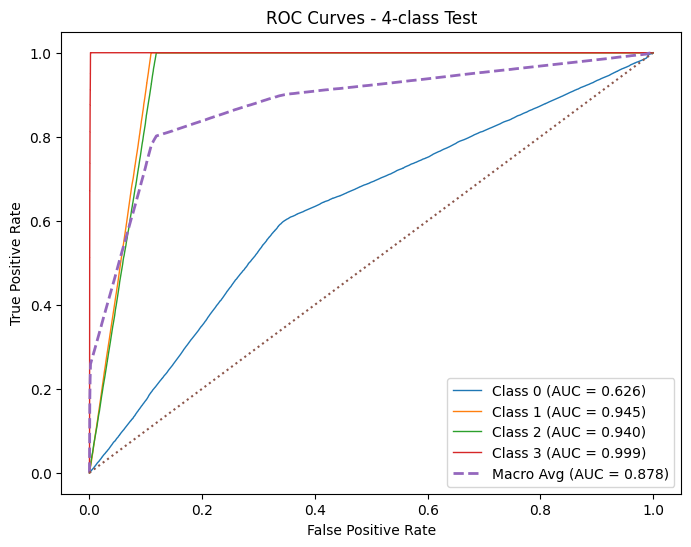


ROC saved to: /content/drive/My Drive/Ensemble model training/ADASYN_4Class_LightGBM/roc_curve_test.png


In [19]:
# Save ROC plot
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], linewidth=1,
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["macro"], tpr["macro"], linewidth=2, linestyle='--',
         label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})")
plt.plot([0,1], [0,1], linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test")
plt.legend()
roc_path = f"{model_dir}/roc_curve_test.png"
plt.savefig(roc_path)
plt.show()
print("\nROC saved to:", roc_path)